<a href="https://colab.research.google.com/github/candrajulius/Pengenalan_Expresi_Wajah_Dengan_Model_AlexNet/blob/main/Pengenalan_Face_Expression_Dengan_AlexNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mengecek GPU
import tensorflow as tf
tf.test.gpu_device_name()

'/device:GPU:0'

In [2]:
# Install Data From Kaggle
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"candrajuliussinaga","key":"12152c98780274ac7b7c7a47f564a628"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [5]:
!kaggle datasets download -d davilsena/ckdataset

Dataset URL: https://www.kaggle.com/datasets/davilsena/ckdataset
License(s): CC0-1.0


In [6]:
file_name = 'ckdataset.zip'

In [7]:
from zipfile import ZipFile
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('Selesai mengekstrak zip')

Selesai mengekstrak zip


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  920 non-null    int64 
 1   pixels   920 non-null    object
 2   Usage    920 non-null    object
dtypes: int64(1), object(2)
memory usage: 21.7+ KB
None
          emotion
count  920.000000
mean     4.920652
std      1.882630
min      0.000000
25%      5.000000
50%      6.000000
75%      6.000000
max      7.000000
emotion    0
pixels     0
Usage      0
dtype: int64
emotion
0     45
1     59
2     25
3     69
4     28
5     83
6    593
7     18
Name: count, dtype: int64


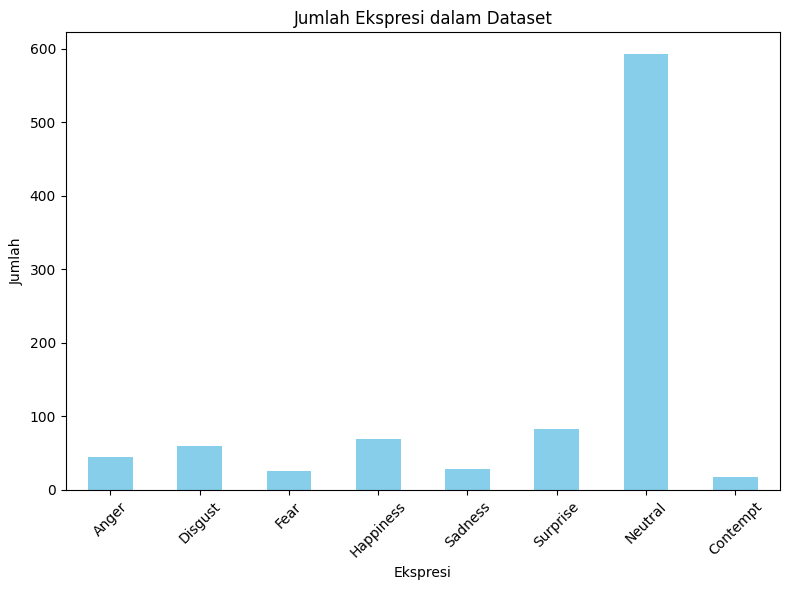

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca CSV
df = pd.read_csv('ckextended.csv')

# Gather information about dataset
print(df.info())
print(df.describe())
print(df.isnull().sum())

emotion_labels = {
    0: "Anger",
    1: "Disgust",
    2: "Fear",
    3: "Happiness",
    4: "Sadness",
    5: "Surprise",
    6: "Neutral",
    7: "Contempt"
}

print(df['emotion'].value_counts().sort_index())

expression = df['emotion'].value_counts().sort_index()
expression.index = expression.index.map(emotion_labels)

# Buat bar chart
plt.figure(figsize=(8,6))
expression.plot(kind='bar', color='skyblue')
plt.title('Jumlah Ekspresi dalam Dataset')
plt.xlabel('Ekspresi')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

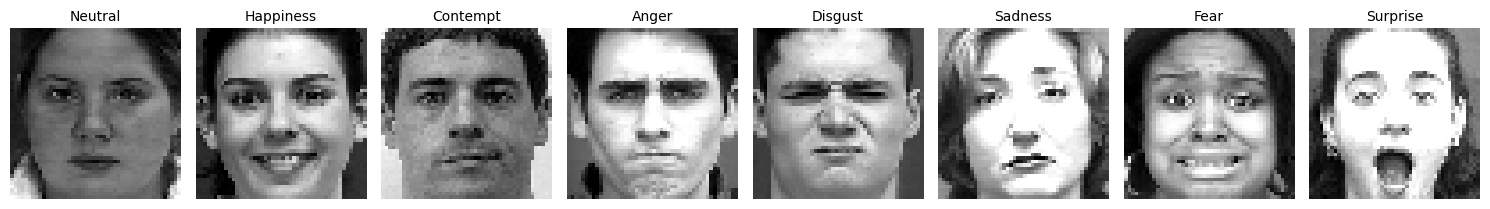

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Buat dict untuk simpan gambar sample per label
samples = {}

# Loop semua baris, ambil satu sample per label
for _, row in df.iterrows():
    label = row['emotion']
    if label not in samples:
        # Ubah string pixel menjadi array
        pixels = np.array(row['pixels'].split(), dtype='float32')
        image = pixels.reshape(48, 48)  # ukuran default FER-2013
        samples[label] = image

    if len(samples) == len(emotion_labels):
        break  # sudah cukup semua label

# Tampilkan
plt.figure(figsize=(15, 5))
for idx, (label, image) in enumerate(samples.items()):
    plt.subplot(1, len(samples), idx + 1)
    plt.imshow(image, cmap='gray')
    plt.title(emotion_labels[label], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [54]:
X = df['pixels'].apply(lambda x: np.fromstring(x, sep=' '))
X = np.array([i for i in X])  # Listeyi numpy array'e çevir
y = df['emotion']

In [55]:
# Resimleri 48x48 boyutuna çevir (her resim için 48x48 = 2304 piksel)
X = X.reshape(-1, 48, 48, 1).astype('float32')

In [56]:
# Veriyi normalize et (0-255 arası piksel değerini 0-1 arasına çekiyoruz)
X /= 255.0

In [57]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
# Etiketleri kategorik hale getir (one-hot encoding)
y = to_categorical(y, num_classes=8)  # FER2013'te 7 farklı duygu var

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Eğitim verisi boyutu: {X_train.shape}')
print(f'Test verisi boyutu: {X_test.shape}')

Eğitim verisi boyutu: (736, 48, 48, 1)
Test verisi boyutu: (184, 48, 48, 1)


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

model = Sequential()

# Layer 1: Conv + ReLU + Pool
model.add(Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01), input_shape=(48, 48, 1)))
model.add(MaxPooling2D((2, 2)))

# Layer 2: Conv + ReLU + Pool
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Layer 3: Conv + ReLU + Pool
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# FC Layer
model.add(Flatten())
model.add(Dense(512, activation='relu'))  # agak besar biar mirip FC di AlexNet
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(8, activation='softmax'))  # 8 kelas ekspresi

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,471,432 (9.43 MB)

 Trainable params: 2,471,432 (9.43 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 493ms/step - accuracy: 0.6017 - loss: 1.8462 - val_accuracy: 0.6413 - val_loss: 1.3983
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6172 - loss: 1.4930 - val_accuracy: 0.6413 - val_loss: 1.3624
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6517 - loss: 1.3439 - val_accuracy: 0.6413 - val_loss: 1.3569
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6347 - loss: 1.3591 - val_accuracy: 0.6413 - val_loss: 1.3533
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6486 - loss: 1.3242 - val_accuracy: 0.6413 - val_loss: 1.3477
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6600 - loss: 1.3065 - val_accuracy: 0.6413 - val_loss: 1.3447
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6521 - loss: 1.3188 - val_accuracy: 0.6413 - val_loss: 1.3369
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6189 - loss: 1.3789 - val_accuracy: 0.6413 -

In [62]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step


# Confusion Matrix Testing

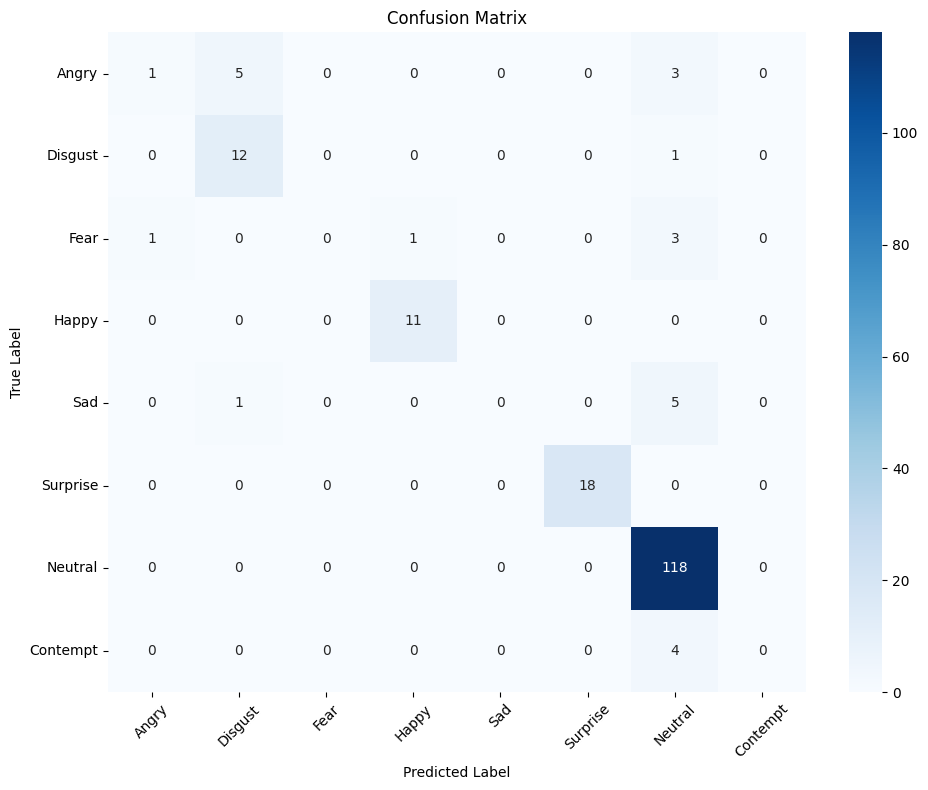


Classification Report:
              precision    recall  f1-score   support

       Angry       0.50      0.11      0.18         9
     Disgust       0.67      0.92      0.77        13
        Fear       0.00      0.00      0.00         5
       Happy       0.92      1.00      0.96        11
         Sad       0.00      0.00      0.00         6
    Surprise       1.00      1.00      1.00        18
     Neutral       0.88      1.00      0.94       118
    Contempt       0.00      0.00      0.00         4

    accuracy                           0.87       184
   macro avg       0.50      0.50      0.48       184
weighted avg       0.79      0.87      0.82       184



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Label kelas (ganti sesuai dataset kamu ya)
class_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral', 'Contempt']

# Confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes, target_names=class_labels))

In [67]:
y_pred = model.predict(X_train)
y_pred_classes_train = np.argmax(y_pred, axis=1)
y_train_classes = np.argmax(y_train, axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


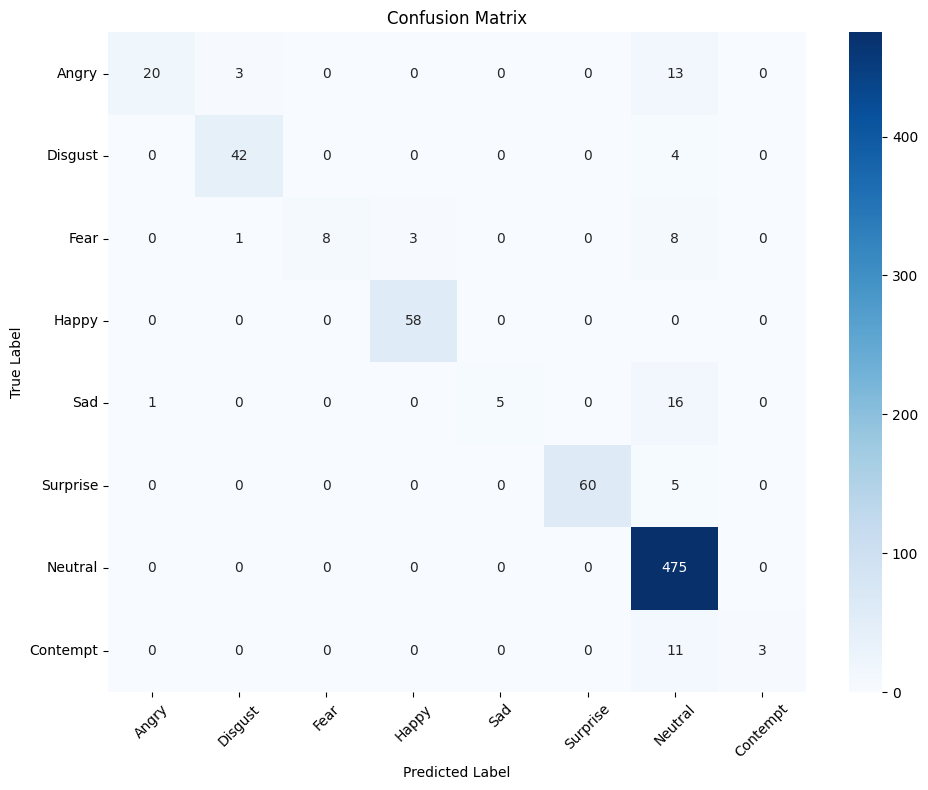


Classification Report:
              precision    recall  f1-score   support

       Angry       0.95      0.56      0.70        36
     Disgust       0.91      0.91      0.91        46
        Fear       1.00      0.40      0.57        20
       Happy       0.95      1.00      0.97        58
         Sad       1.00      0.23      0.37        22
    Surprise       1.00      0.92      0.96        65
     Neutral       0.89      1.00      0.94       475
    Contempt       1.00      0.21      0.35        14

    accuracy                           0.91       736
   macro avg       0.96      0.65      0.72       736
weighted avg       0.92      0.91      0.90       736



In [68]:
# Label kelas (ganti sesuai dataset kamu ya)
class_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral', 'Contempt']

# Confusion matrix
cm = confusion_matrix(y_train_classes, y_pred_classes_train)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_train_classes, y_pred_classes_train, target_names=class_labels))

In [69]:
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f'Akurasi Training: {train_accuracy * 100:.2f}%')

# Evaluasi akurasi testing
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Akurasi Testing: {test_accuracy * 100:.2f}%')

Akurasi Training: 91.17%
Akurasi Testing: 86.96%


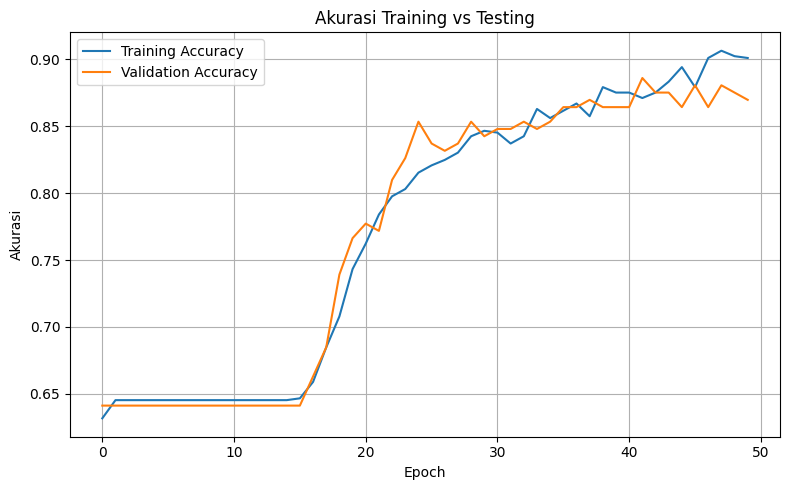

In [70]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Akurasi Training vs Testing')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

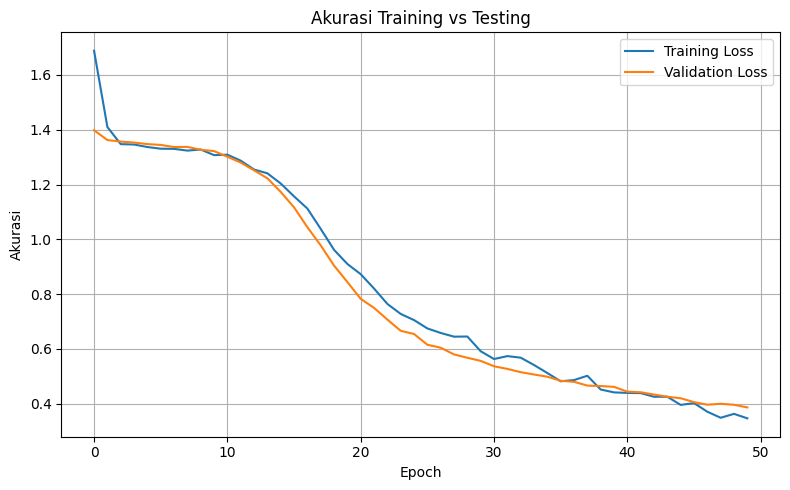

In [72]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Akurasi Training vs Testing')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()